# Evaluación de Modelos de Regresión

En este laboratorio vamos a evaluar el modelo Random Forest aplicado a regresión.

### SETUP


In [1]:
!pip install -q numpy==2.2.0
!pip install -q pandas==2.2.3
!pip install -q scikit-learn==1.6.0
!pip install -q matplotlib==3.9.3
!pip install -q scipy==1.14.1

In [2]:
#Importamos librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew

# Descargamos dataset
data = fetch_california_housing()
X, y = data.data, data.target

## Estudio del Dataset

En este caso vamos a utilizar un dataset inmobiliario del estado de California, lamentablemente no encontré un dataset similar que cubra la región de CABA así que vamos con este.

In [ ]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Bien, podemos observar  un par de cosas, primero que nada el dataset lógicamente esta bastante pulido y no requiere que le hagamos ningún tipo de preprocesamiento. Por otro lado y tal como lo indica la descripción lo que vamos a predecir (AKA nuestra variable objetivo) es el valor medio expresado en cientos de miles de dolares. Veamos un poco la distribución del dataset



Text(0, 0.5, 'Frecuencia')

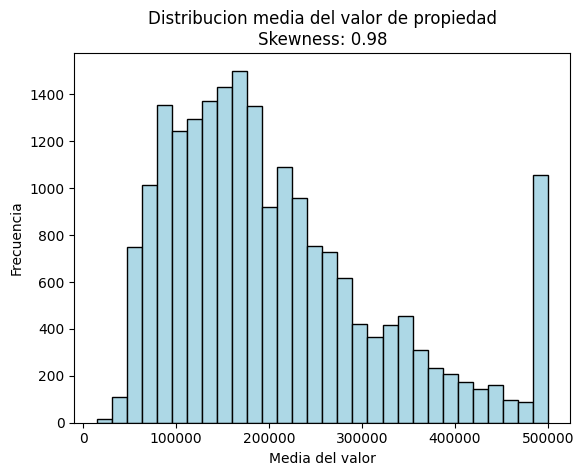

In [8]:
# Distribucion
plt.hist(1e5*data.target, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Distribucion media del valor de propiedad\nSkewness: {skew(data.target):.2f}')
plt.xlabel('Media del valor')
plt.ylabel('Frecuencia')

Podemos ver que la mayor parte de las propiedades rondan los 160-180 mil USD, en particular es evidente que la distribución es asimétrica, veremos mas adelante que impacto trae en las predicciones

## Creación de Modelo

Pasemos entonces a la separación de nuestro Dataset en validación y entrenamiento, luego creemos y entrenemos el modelo de Random Forests.

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=10)
rf_regressor.fit(X_train, Y_train)

RandomForestRegressor(random_state=10)

Finalmente podemos realizar las predicciones y sacar métricas sobre las mismas

In [18]:
#Predecimos
Y_predicted = rf_regressor.predict(X_test)


#Calculamos métricas
mae = mean_absolute_error(Y_test, Y_predicted)
mse = mean_squared_error(Y_test, Y_predicted)
rmse = root_mean_squared_error(Y_test, Y_predicted)
r2 = r2_score(Y_test, Y_predicted)
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score: {r2:.3f}")


Mean Absolute Error (MAE): 0.328
Mean Squared Error (MSE): 0.255
Root Mean Squared Error (RMSE): 0.505
R² Score: 0.805


Observemos estos resultados, lo mas notorio podría ser el valor MSe, que es bastante bajo teniendo en cuenta la escala de nuestro objetivo, en particular indica que nuestras predicciones van a tener un error aproximado de 32.000 USD. <br>
En general, teniendo en cuenta la distribución de los datos que vimos en el estudio del Dataset es altamente probable que haya una sobreestimación de las propiedades mas baratas y una subestimación del valor de las propiedades mas caras, dado que estas eran las outliers que probablemente generan la mayor perdida de precisión.

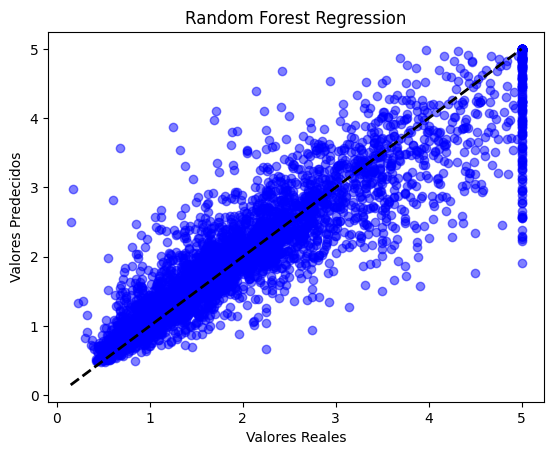

In [19]:
plt.scatter(Y_test, Y_predicted, alpha=0.5, color="blue")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predecidos")
plt.title("Random Forest Regression")
plt.show()

Efectivamente, este gráfico indica la suposición que tuvimos en base a la imparidad de los datos, podemos ver como los valores reales bajos tienen predicciones elevadas, mientras que los valores reales altos tienden a ser subestimados.